In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding, TSNE
from sklearn.datasets import fetch_openml


print('Good imports!')

Good imports!


In [2]:
def average_distance(dimensions):
    points = np.random.rand(1000, dimensions)
    dist_matrix = euclidean_distances(points, points)
    return np.mean(dist_matrix[dist_matrix > 0])

print("--- Математическое доказательство проклятия размерности ---")
print(f"Среднее расстояние в 2D (плоскость): {average_distance(2):.4f}")
print(f"Среднее расстояние в 3D (наш мир):    {average_distance(3):.4f}")
print(f"Среднее расстояние в 50D:             {average_distance(50):.4f}")
print(f"Среднее расстояние в 500D (космос):   {average_distance(500):.4f}")

--- Математическое доказательство проклятия размерности ---
Среднее расстояние в 2D (плоскость): 0.5177
Среднее расстояние в 3D (наш мир):    0.6579
Среднее расстояние в 50D:             2.8732
Среднее расстояние в 500D (космос):   9.1295


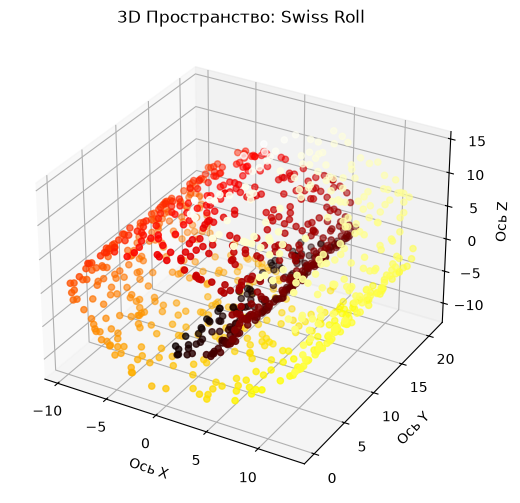

In [3]:
X_swiss, t_swiss = make_swiss_roll(n_samples=1000, noise=0.1, random_state=42)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t_swiss, cmap=plt.cm.hot)

ax.set_title("3D Пространство: Swiss Roll")
ax.set_xlabel("Ось X")
ax.set_ylabel("Ось Y")
ax.set_zlabel("Ось Z")
plt.show()

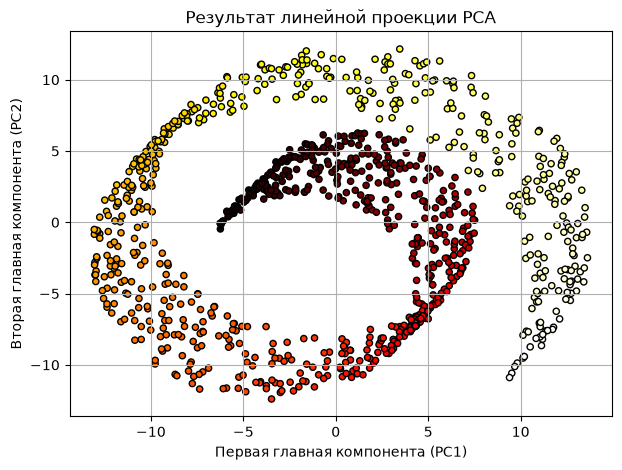

In [6]:
pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(X_swiss)

pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(X_swiss)

plt.figure(figsize=(7, 5))
plt.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=t_swiss, cmap=plt.cm.hot, edgecolor='k', s=20)
plt.title("Результат линейной проекции PCA")
plt.xlabel("Первая главная компонента (PC1)")
plt.ylabel("Вторая главная компонента (PC2)")
plt.grid(True)
plt.show()

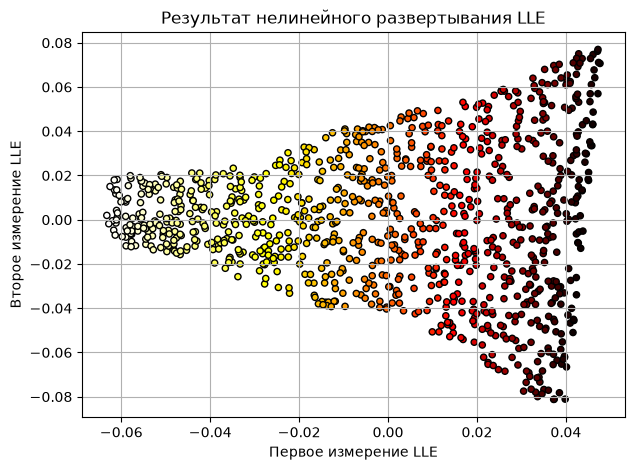

In [11]:
lle = LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=42)
X_reduced_lle = lle.fit_transform(X_swiss)

plt.figure(figsize=(7, 5))
plt.scatter(X_reduced_lle[:, 0], X_reduced_lle[:, 1], c=t_swiss, cmap=plt.cm.hot, edgecolor='k', s=20)
plt.title("Результат нелинейного развертывания LLE")
plt.xlabel("Первое измерение LLE")
plt.ylabel("Второе измерение LLE")
plt.grid(True)
plt.show()

Загрузка кусочка MNIST...
Оригинальное количество признаков: 784
Количество признаков после сжатия:  148


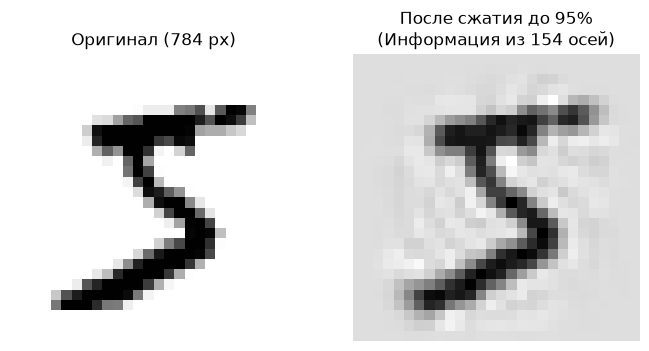

In [13]:
print("Загрузка кусочка MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_mnist = mnist["data"][:5000]
y_mnist = mnist["target"][:5000]

pca_95 = PCA(n_components=0.95)
X_mnist_reduced = pca_95.fit_transform(X_mnist)

print(f"Оригинальное количество признаков: {X_mnist.shape[1]}")
print(f"Количество признаков после сжатия:  {X_mnist_reduced.shape[1]}")

X_mnist_recovered = pca_95.inverse_transform(X_mnist_reduced)

plt.figure(figsize=(7, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(X_mnist[0].reshape(28, 28), cmap="binary")
plt.title("Оригинал (784 px)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_mnist_recovered[0].reshape(28, 28), cmap="binary")
plt.title("После сжатия до 95%\n(Информация из 154 осей)")
plt.axis("off")

plt.tight_layout()
plt.show()

t-SNE строит карту данных...


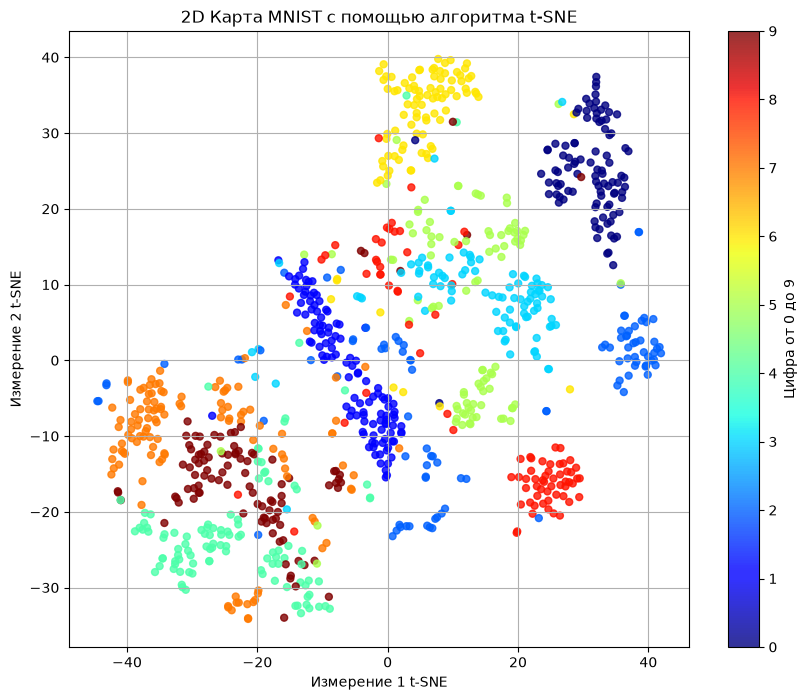

In [16]:
X_tsne_data = X_mnist[:1000]
y_tsne_labels = y_mnist[:1000].astype(int)

print("t-SNE строит карту данных...")
tsne = TSNE(n_components=2, init="pca", learning_rate="auto", random_state=42)
X_reduced_tsne = tsne.fit_transform(X_tsne_data)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=y_tsne_labels, cmap="jet", alpha=0.8, s=25)
plt.colorbar(scatter, label="Цифра от 0 до 9")
plt.title("2D Карта MNIST с помощью алгоритма t-SNE")
plt.xlabel("Измерение 1 t-SNE")
plt.ylabel("Измерение 2 t-SNE")
plt.grid(True)
plt.show()